# eBPF Performance Bottleneck Analysis

Each row = one (pid, cpu) observation from one collection session.
No grouping by process — we treat every row as a feature vector and ask:
**do the metric values differ between bottleneck types?**

That is exactly what the ML classifier will learn.

## Cell 1 — Config & style

In [12]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import numpy as np
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

CSV_PATH = 'perf_metrics.csv'
OUT_DIR  = './plots'
os.makedirs(OUT_DIR, exist_ok=True)

BG    = '#0d1117'
AXES  = '#161b22'
GRID  = '#21262d'
TEXT  = '#c9d1d9'
MUTED = '#484f58'

LABEL_COLORS = {
    'cpu_bound':    '#f87171',
    'memory_bound': '#60a5fa',
    'io_bound':     '#4ade80',
    'contention':   '#fb923c',
    'mixed':        '#c084fc',
    'unknown':      '#6b7280',
}
C = ['#60a5fa','#f87171','#4ade80','#fb923c','#c084fc','#facc15','#34d399','#f472b6']

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor':  AXES,
    'axes.edgecolor':  GRID,  'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,  'xtick.color':     MUTED,
    'ytick.color':     MUTED, 'text.color':      TEXT,
    'grid.color':      GRID,  'grid.linewidth':  0.6,
    'lines.linewidth': 1.2,   'font.family':     'monospace',
    'font.size':       10,    'axes.titlesize':  11,
    'axes.labelsize':  9,     'legend.facecolor':AXES,
    'legend.edgecolor':GRID,  'legend.labelcolor':TEXT,
    'legend.fontsize': 8,     'savefig.bbox':    'tight',
    'savefig.facecolor':BG,   'savefig.dpi':     150,
})

def savefig(fig, name):
    fig.savefig(os.path.join(OUT_DIR, name))
    print(f'saved → {OUT_DIR}/{name}')

def legend_patches(labels):
    return [Patch(color=LABEL_COLORS.get(l, MUTED), alpha=0.8, label=l) for l in labels]

print('Config ready.')

Config ready.


## Cell 2 — Load data

In [13]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')

# ns → µs for readability
for c in [col for col in df.columns if col.endswith('_ns')]:
    df[c.replace('_ns','_us')] = df[c] / 1000.0

# derived columns
df['total_faults'] = df.get('minor_faults', 0) + df.get('kernel_faults', 0)
df['total_lock_contentions'] = (
    df.get('mutex_contentions', 0) +
    df.get('rwsem_read_contentions', 0) +
    df.get('rwsem_write_contentions', 0)
)
# involuntary % — key CPU bottleneck indicator
df['involuntary_pct'] = np.where(
    df['ctx_switches'] > 0,
    df['involuntary_switches'] / df['ctx_switches'] * 100, 0
)
# row index as sequence proxy
df['row_idx'] = np.arange(len(df))

df['label'] = df['label'].fillna('unknown')
labels = sorted(df['label'].unique())
label_colors = [LABEL_COLORS.get(l, MUTED) for l in df['label']]

print(f'Labels: {labels}')
print(f'Rows per label:')
print(df['label'].value_counts().to_string())

Loaded 2,588 rows, 41 columns
Labels: ['cpu_bound']
Rows per label:
label
cpu_bound    2588


---
## Figure 1 — Raw metric values across all rows, coloured by label

X axis = row index (sequence order).  
Each dot = one (pid, cpu) observation.  
**If labels cluster separately on Y → that metric is a good bottleneck signal.**

This is the most direct view of whether your data is separable.

saved → ./plots/01_scatter_by_label.png


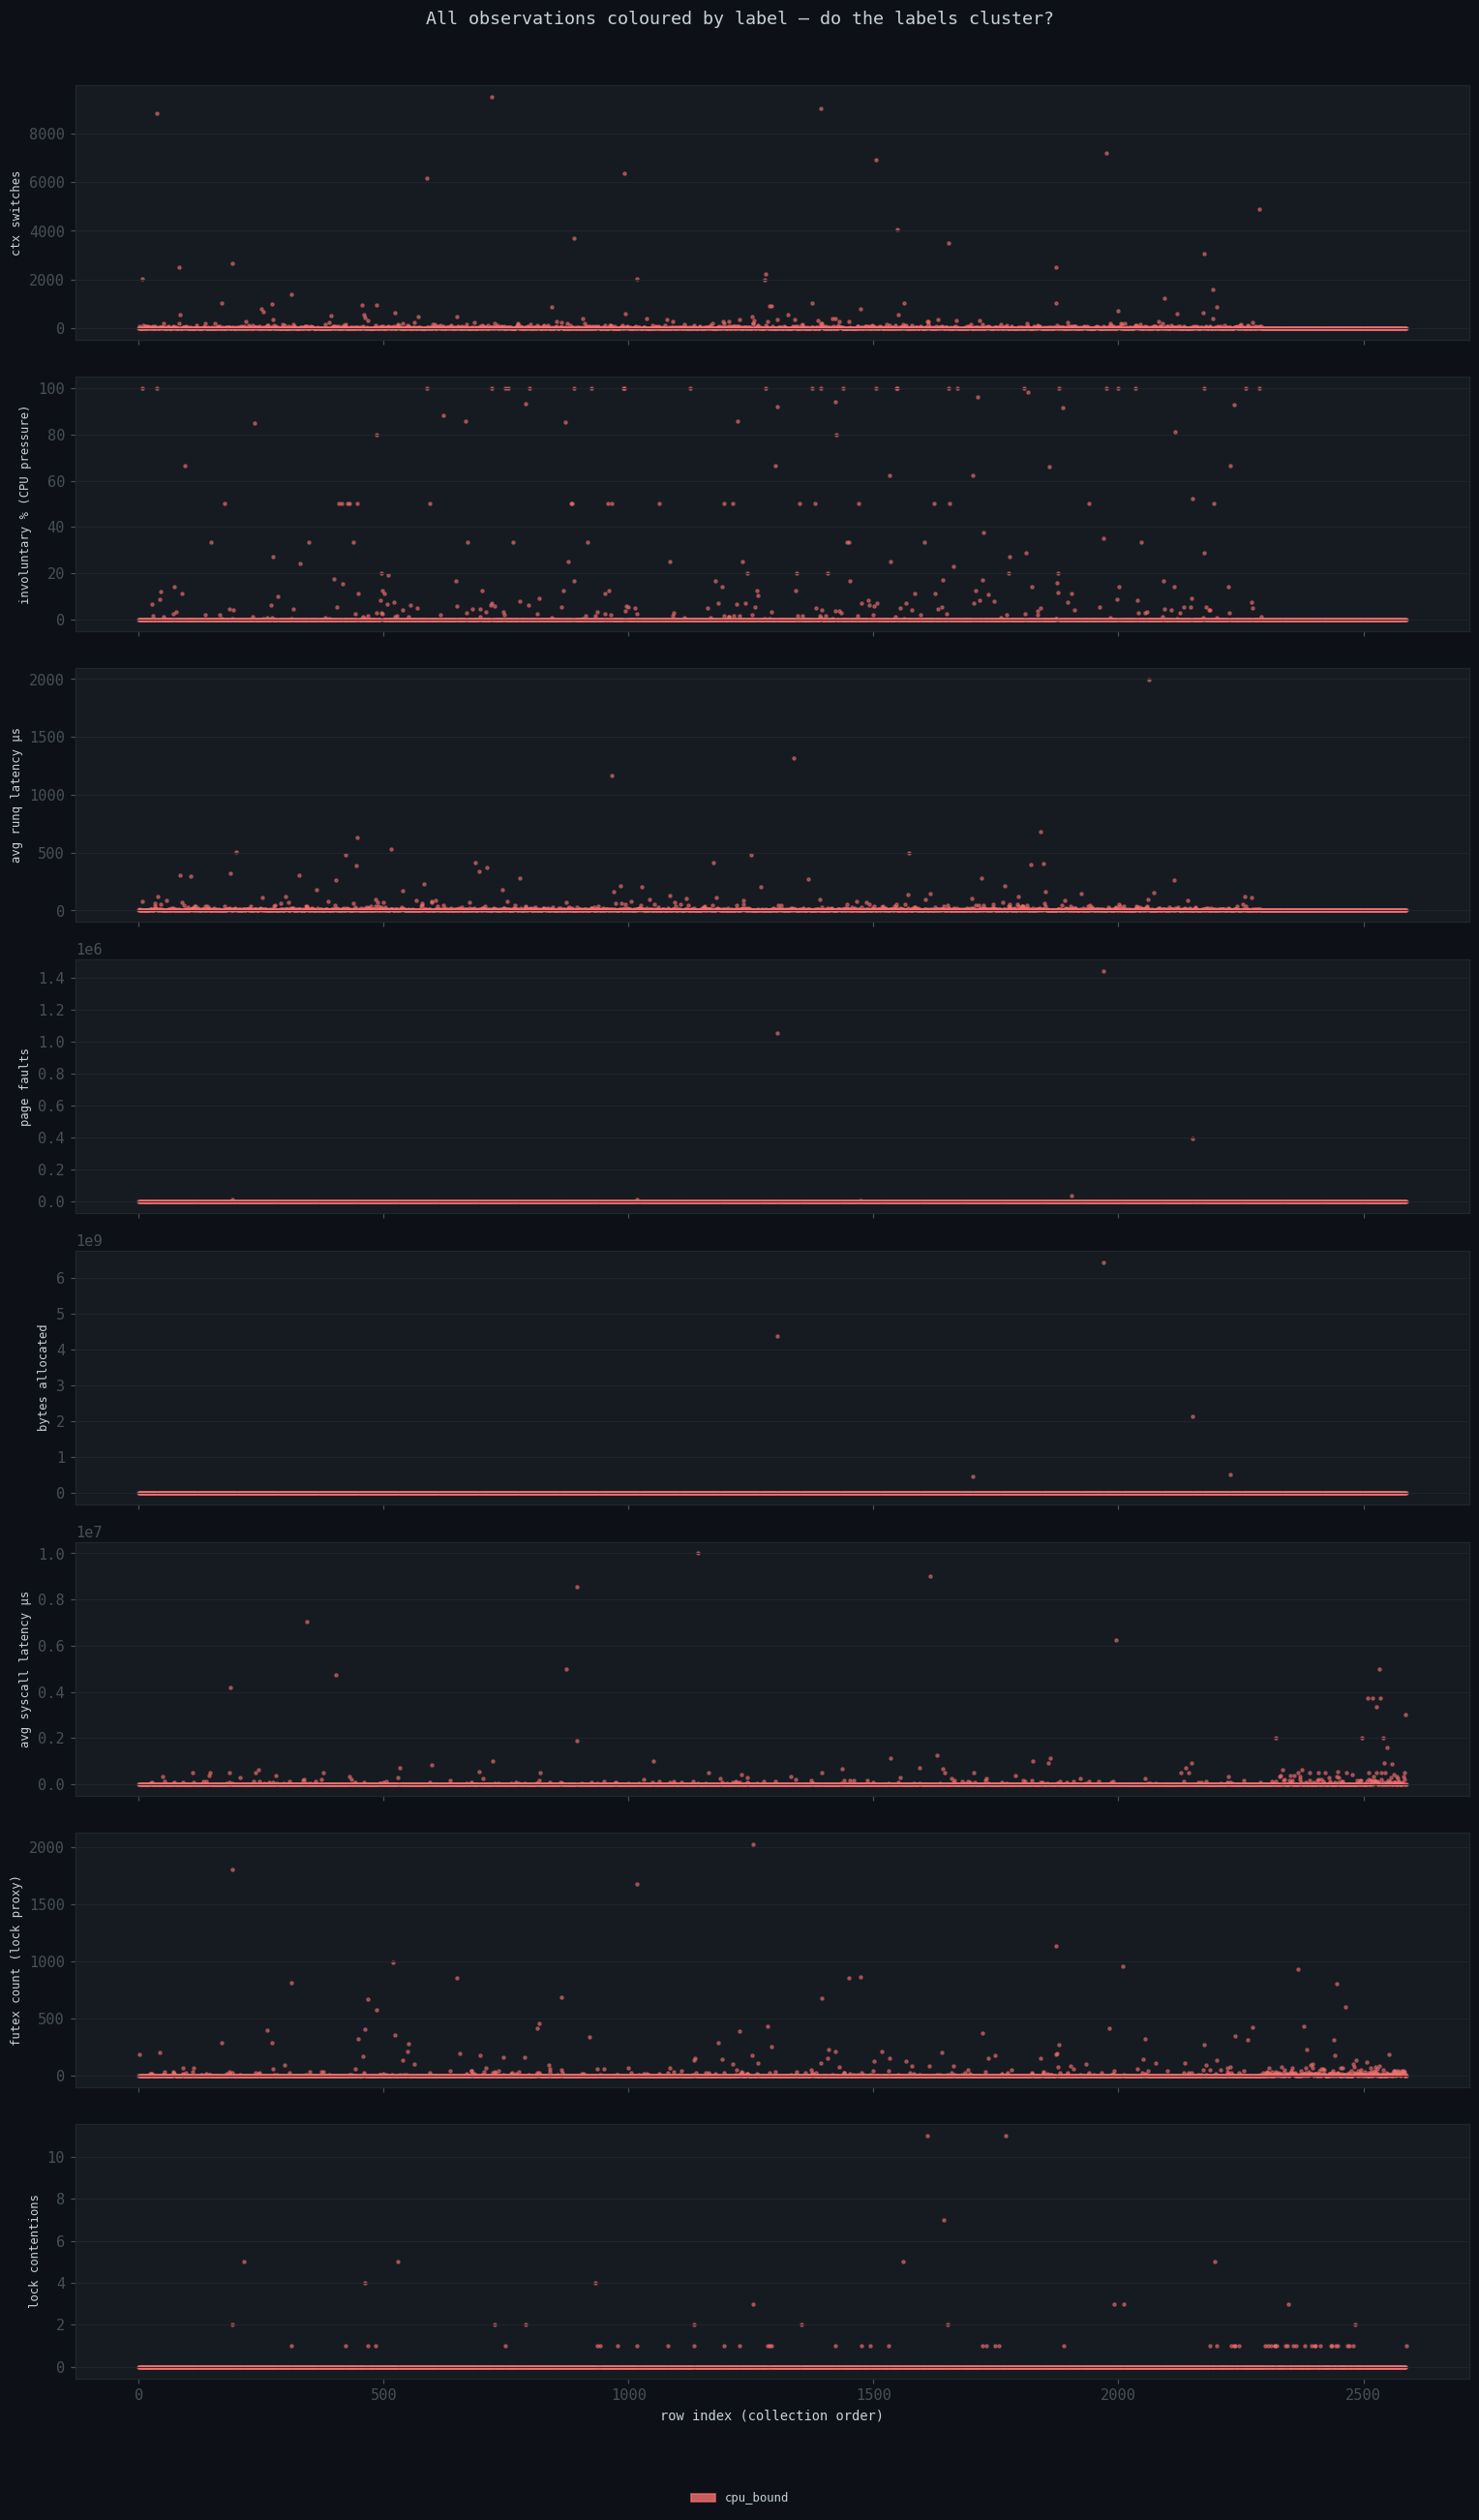

In [14]:
key_metrics = [
    ('ctx_switches',           'ctx switches'),
    ('involuntary_pct',        'involuntary % (CPU pressure)'),
    ('avg_runq_latency_us',    'avg runq latency µs'),
    ('total_faults',           'page faults'),
    ('total_alloc_bytes',      'bytes allocated'),
    ('avg_syscall_latency_us', 'avg syscall latency µs'),
    ('futex_count',            'futex count (lock proxy)'),
    ('total_lock_contentions', 'lock contentions'),
]
key_metrics = [(m, l) for m, l in key_metrics if m in df.columns]

n = len(key_metrics)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
fig.suptitle('All observations coloured by label — do the labels cluster?', fontsize=12)

for ax, (col, ylabel) in zip(axes, key_metrics):
    for lbl in labels:
        mask = df['label'] == lbl
        ax.scatter(df.loc[mask, 'row_idx'], df.loc[mask, col],
                   c=LABEL_COLORS.get(lbl, MUTED), s=4, alpha=0.5, label=lbl)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(True, axis='y')

axes[-1].set_xlabel('row index (collection order)')
fig.legend(handles=legend_patches(labels), loc='lower center',
           ncol=len(labels), frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
savefig(fig, '01_scatter_by_label.png')
plt.show()

---
## Figure 2 — Boxplots per label per metric

Same data as Figure 1 but summarised as distributions.  
**Non-overlapping boxes = that metric cleanly separates bottleneck types.**  
This tells you directly which features will be most useful for the classifier.

In [15]:
if len(labels) < 2:
    print(f'Need 2+ labels. Currently have: {labels}. Collect more workloads.')
else:
    key_metrics = [
        ('ctx_switches',           'ctx switches'),
        ('involuntary_pct',        'involuntary %'),
        ('avg_runq_latency_us',    'runq latency µs'),
        ('cpu_migrations',         'CPU migrations'),
        ('total_faults',           'page faults'),
        ('total_alloc_bytes',      'bytes allocated'),
        ('avg_syscall_latency_us', 'syscall latency µs'),
        ('futex_count',            'futex count'),
        ('total_lock_contentions', 'lock contentions'),
        ('read_bytes',             'read bytes'),
        ('write_bytes',            'write bytes'),
        ('kmalloc_count',          'kmalloc count'),
    ]
    key_metrics = [(m, l) for m, l in key_metrics if m in df.columns]

    cols = 3
    rows = (len(key_metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle('Distribution per label — non-overlapping = good ML feature', fontsize=12)
    axes = axes.flatten()

    for i, (col, ylabel) in enumerate(key_metrics):
        ax = axes[i]
        data   = [df[df['label'] == l][col].dropna().values for l in labels]
        colors = [LABEL_COLORS.get(l, MUTED) for l in labels]
        bp = ax.boxplot(data, labels=labels, patch_artist=True,
                        medianprops={'color': TEXT, 'linewidth': 1.5},
                        boxprops={'linewidth': 0.8},
                        whiskerprops={'linewidth': 0.8},
                        capprops={'linewidth': 0.8},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color); patch.set_alpha(0.6)
        ax.set_title(ylabel, fontsize=9)
        ax.grid(True, axis='y')
        ax.tick_params(axis='x', labelsize=7, rotation=15)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig(fig, '02_boxplots_per_label.png')
    plt.show()

Need 2+ labels. Currently have: ['cpu_bound']. Collect more workloads.


---
## Figure 3 — Bottleneck fingerprint: mean metric value per label (radar / bar)

Normalised mean of each metric per label.  
Each label should have a different 'shape' — that shape is its bottleneck fingerprint.  
High CPU pressure = high involuntary%, high ctx_switches.  
Memory bottleneck = high faults, high alloc bytes.  
I/O bottleneck = high syscall latency, high read/write bytes.  
Lock contention = high futex, high lock contentions.

saved → ./plots/03_fingerprint.png


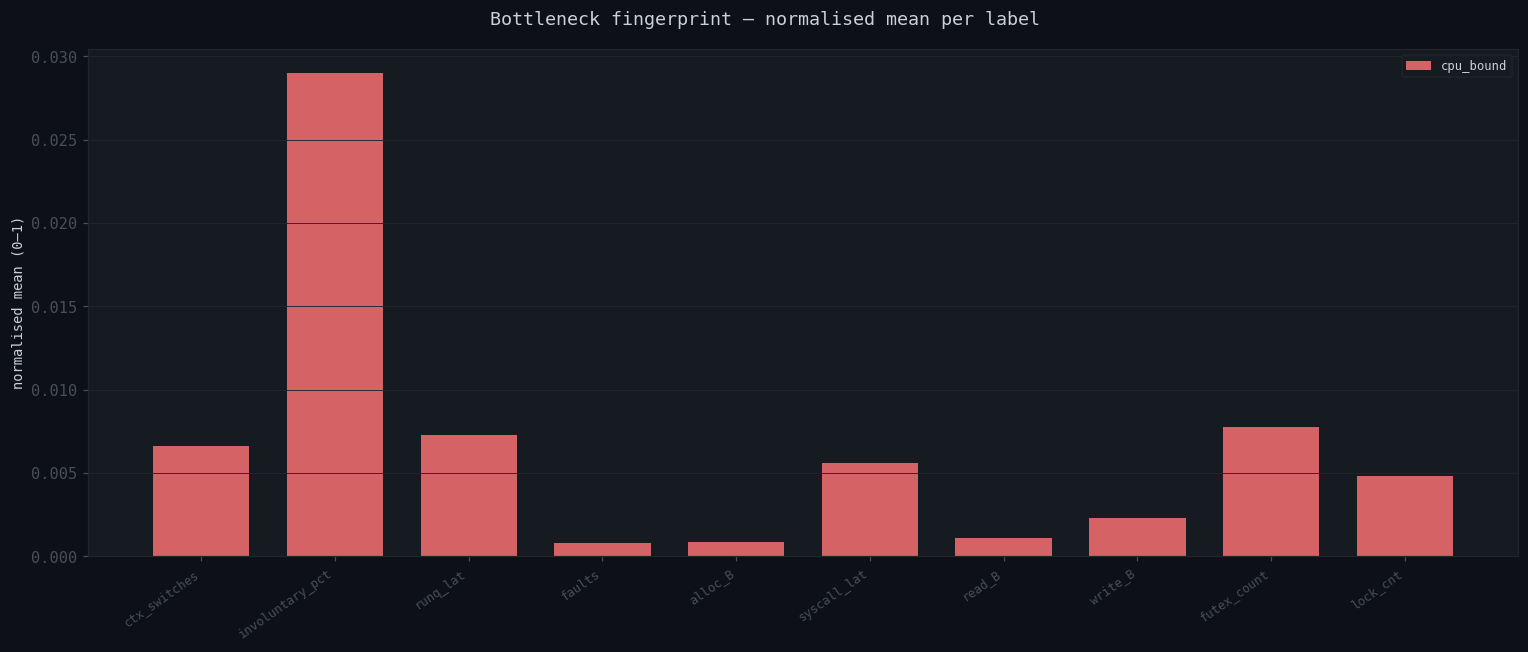

In [16]:
fingerprint_metrics = [
    'ctx_switches', 'involuntary_pct', 'avg_runq_latency_us',
    'total_faults', 'total_alloc_bytes',
    'avg_syscall_latency_us', 'read_bytes', 'write_bytes',
    'futex_count', 'total_lock_contentions',
]
fingerprint_metrics = [m for m in fingerprint_metrics if m in df.columns]

# normalise each metric 0-1 across all rows so they're on the same scale
norm = df[fingerprint_metrics].copy()
for col in fingerprint_metrics:
    mn, mx = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - mn) / (mx - mn + 1e-9)
norm['label'] = df['label']

means = norm.groupby('label')[fingerprint_metrics].mean()

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Bottleneck fingerprint — normalised mean per label', fontsize=12)

x = np.arange(len(fingerprint_metrics))
width = 0.8 / max(len(labels), 1)

for i, lbl in enumerate(means.index):
    offset = (i - len(means.index)/2 + 0.5) * width
    ax.bar(x + offset, means.loc[lbl], width=width * 0.9,
           color=LABEL_COLORS.get(lbl, MUTED), alpha=0.85, label=lbl)

short_names = [m.replace('avg_','').replace('_latency_us','_lat')
                .replace('_bytes','_B').replace('total_','').replace('_contentions','_cnt')
                for m in fingerprint_metrics]
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('normalised mean (0–1)')
ax.legend(loc='upper right')
ax.grid(True, axis='y')

plt.tight_layout()
savefig(fig, '03_fingerprint.png')
plt.show()

---
## Figure 4 — Correlation heatmap
Which features are redundant? Pairs with correlation > 0.9 mean you only need one of them for the classifier.

saved → ./plots/04_correlation.png


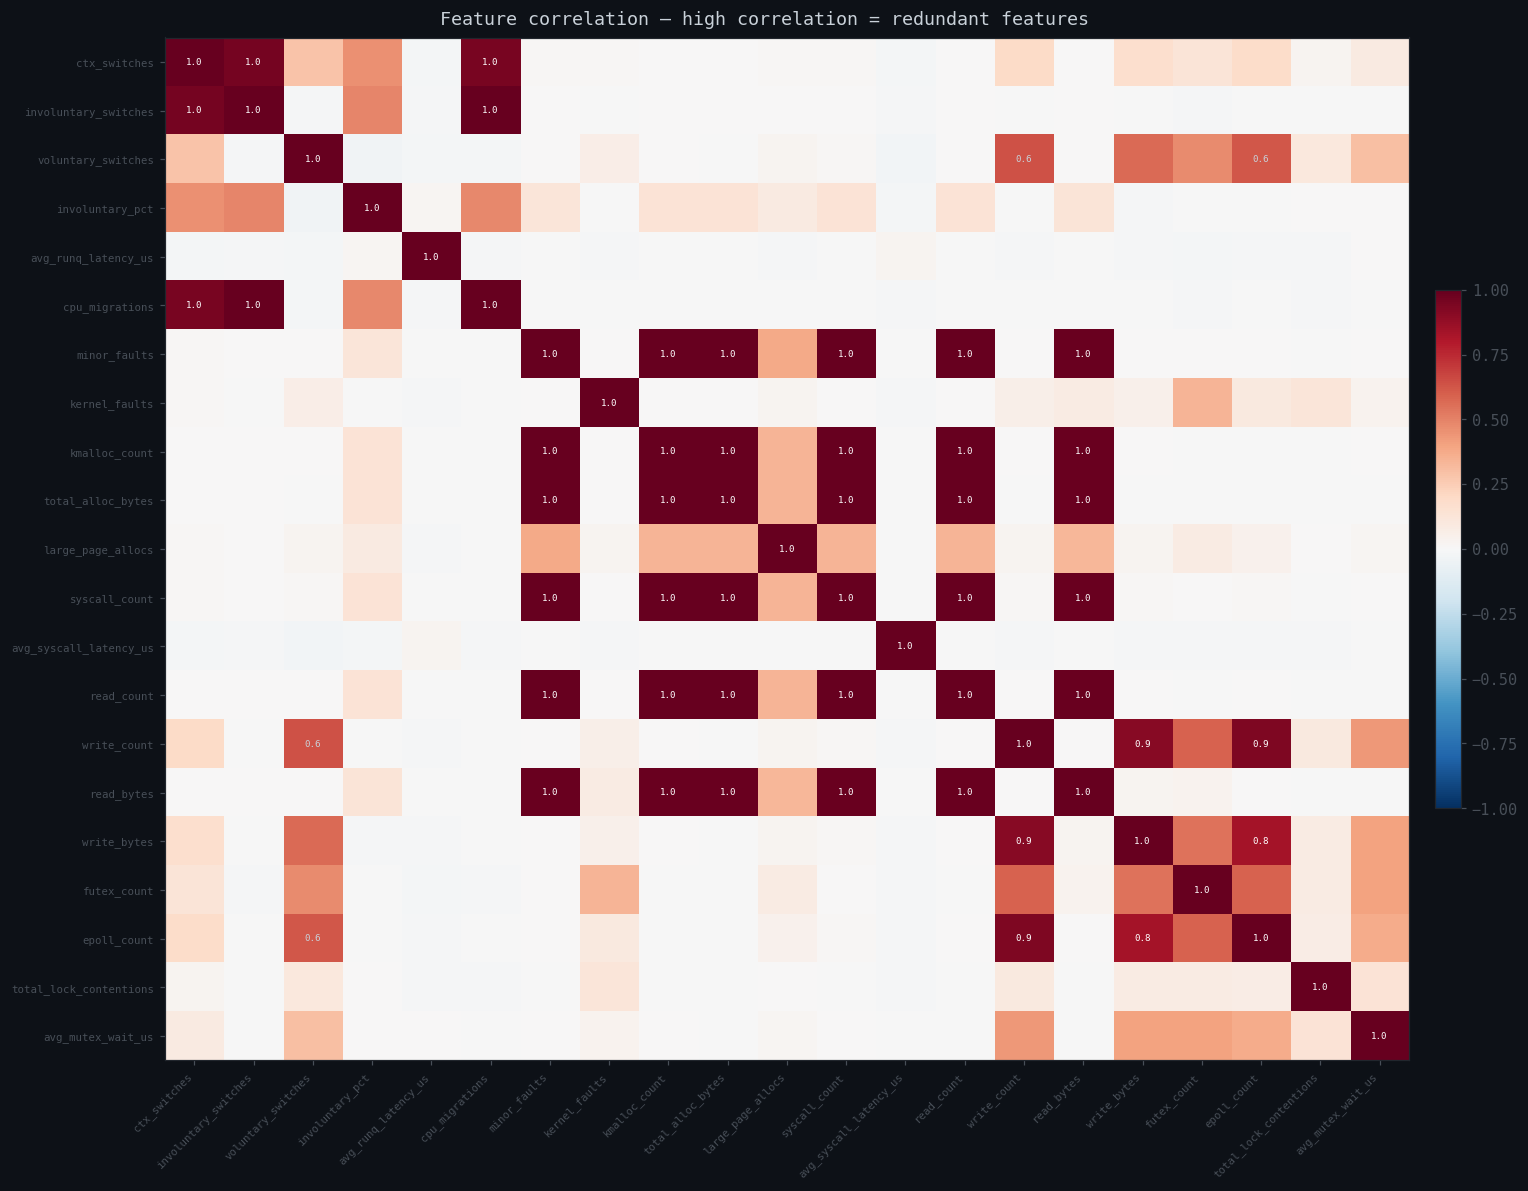

In [17]:
corr_cols = [
    'ctx_switches', 'involuntary_switches', 'voluntary_switches',
    'involuntary_pct', 'avg_runq_latency_us', 'cpu_migrations',
    'minor_faults', 'kernel_faults', 'kmalloc_count',
    'total_alloc_bytes', 'large_page_allocs',
    'syscall_count', 'avg_syscall_latency_us',
    'read_count', 'write_count', 'read_bytes', 'write_bytes',
    'futex_count', 'epoll_count',
    'total_lock_contentions', 'avg_mutex_wait_us',
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Feature correlation — high correlation = redundant features', fontsize=12)
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(corr_cols, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        if abs(v) > 0.6:
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(v) > 0.8 else TEXT)
plt.tight_layout()
savefig(fig, '04_correlation.png')
plt.show()

---
## Figure 5 — 2D scatter: pairs of metrics, coloured by label

If two metrics together separate labels into distinct clouds → strong feature pair for ML.  
Classic expected patterns:  
- cpu_bound: high involuntary%, high ctx_switches  
- memory_bound: high faults, high alloc bytes  
- io_bound: high syscall latency, high read/write bytes  
- contention: high futex, high lock contentions

saved → ./plots/05_feature_pairs.png


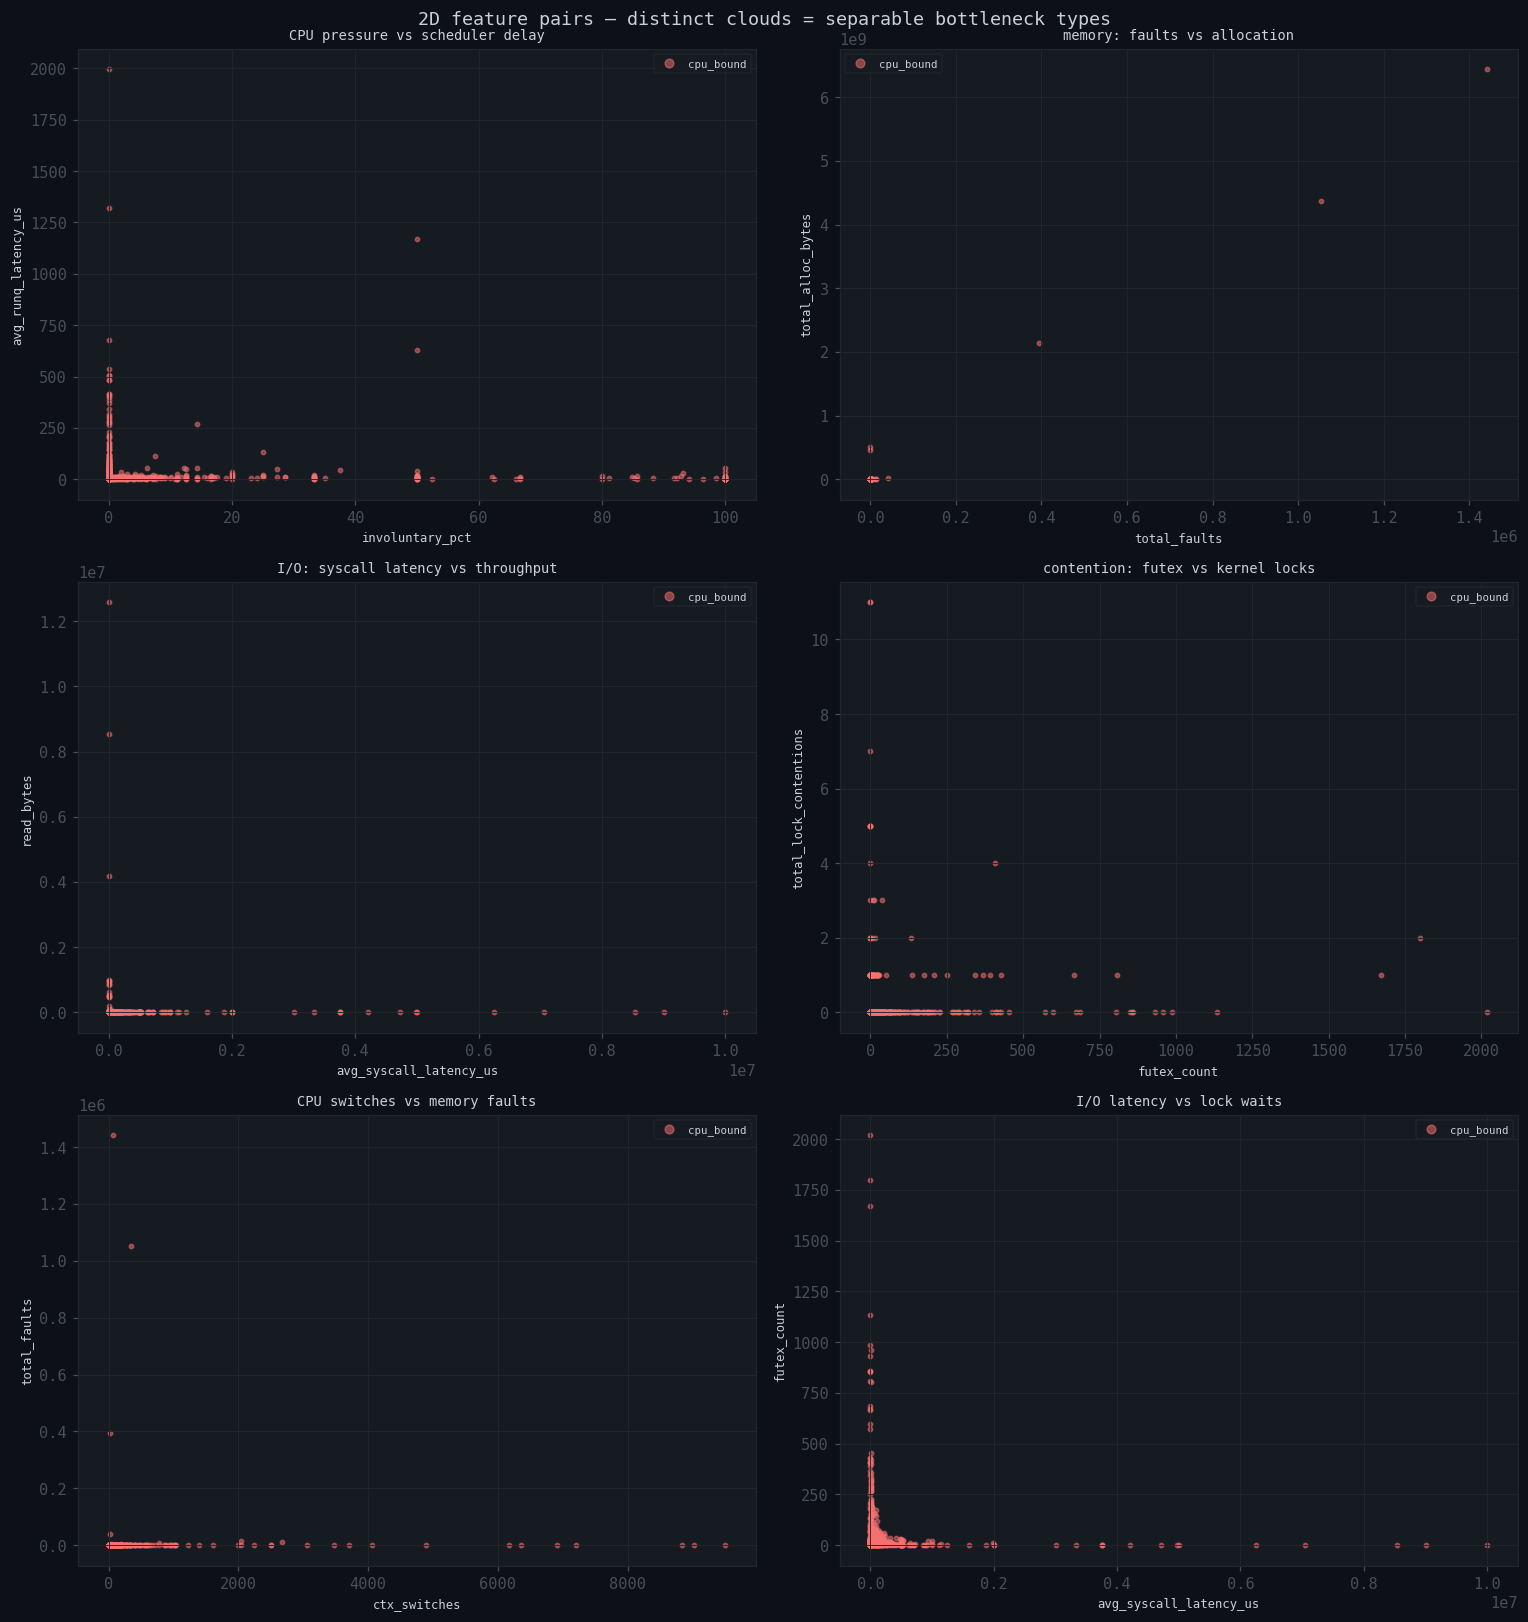

In [18]:
pairs = [
    ('involuntary_pct',        'avg_runq_latency_us',    'CPU pressure vs scheduler delay'),
    ('total_faults',           'total_alloc_bytes',      'memory: faults vs allocation'),
    ('avg_syscall_latency_us', 'read_bytes',             'I/O: syscall latency vs throughput'),
    ('futex_count',            'total_lock_contentions', 'contention: futex vs kernel locks'),
    ('ctx_switches',           'total_faults',           'CPU switches vs memory faults'),
    ('avg_syscall_latency_us', 'futex_count',            'I/O latency vs lock waits'),
]
pairs = [(x, y, t) for x, y, t in pairs if x in df.columns and y in df.columns]

cols = 2
rows = (len(pairs) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('2D feature pairs — distinct clouds = separable bottleneck types', fontsize=12)
axes = axes.flatten()

for i, (xcol, ycol, title) in enumerate(pairs):
    ax = axes[i]
    for lbl in labels:
        mask = df['label'] == lbl
        ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                   c=LABEL_COLORS.get(lbl, MUTED), s=8, alpha=0.5, label=lbl)
    ax.set_xlabel(xcol, fontsize=8)
    ax.set_ylabel(ycol, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(True)
    ax.legend(fontsize=7, markerscale=2)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
savefig(fig, '05_feature_pairs.png')
plt.show()

---
## Figure 6 — Per-metric value range per label (violin plots)

Violin = full distribution shape, not just quartiles.  
Narrow tall violin = values tightly clustered (good signal).  
Wide flat violin = high variance (noisy feature).

In [19]:
if len(labels) < 2:
    print('Need 2+ labels for violin comparison.')
else:
    violin_metrics = [
        ('ctx_switches',           'ctx switches'),
        ('involuntary_pct',        'involuntary %'),
        ('total_faults',           'page faults'),
        ('avg_syscall_latency_us', 'syscall latency µs'),
        ('futex_count',            'futex count'),
        ('total_lock_contentions', 'lock contentions'),
    ]
    violin_metrics = [(m, l) for m, l in violin_metrics if m in df.columns]

    cols = 2
    rows = (len(violin_metrics) + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
    fig.suptitle('Distribution shape per label (violin)', fontsize=12)
    axes = axes.flatten()

    for i, (col, ylabel) in enumerate(violin_metrics):
        ax = axes[i]
        data = [df[df['label'] == l][col].dropna().values for l in labels]
        data = [d[d > 0] if len(d[d > 0]) > 1 else d for d in data]  # skip all-zero
        try:
            parts = ax.violinplot(data, positions=range(len(labels)),
                                  showmedians=True, showextrema=False)
            for j, (pc, lbl) in enumerate(zip(parts['bodies'], labels)):
                pc.set_facecolor(LABEL_COLORS.get(lbl, MUTED))
                pc.set_alpha(0.6)
            parts['cmedians'].set_color(TEXT)
        except Exception:
            ax.boxplot(data, labels=labels, patch_artist=False)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=15)
        ax.set_title(ylabel, fontsize=9)
        ax.grid(True, axis='y')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig(fig, '06_violins.png')
    plt.show()

Need 2+ labels for violin comparison.


---
## Summary stats per label
Mean ± std per feature per label — quick sanity check before training.

In [20]:
summary_cols = [
    'ctx_switches', 'involuntary_pct', 'avg_runq_latency_us',
    'total_faults', 'total_alloc_bytes',
    'avg_syscall_latency_us', 'futex_count', 'total_lock_contentions',
]
summary_cols = [c for c in summary_cols if c in df.columns]

if 'label' in df.columns:
    summary = df.groupby('label')[summary_cols].agg(['mean','std','max']).round(1)
    display(summary)
else:
    display(df[summary_cols].describe().round(1))

ctx_switches              involuntary_pct               \
                  mean    std   max            mean   std    max   
label                                                              
cpu_bound         63.1  464.7  9508             2.9  13.9  100.0   

          avg_runq_latency_us               total_faults  ...  \
                         mean   std     max         mean  ...   
label                                                     ...   
cpu_bound                14.5  67.0  1996.2       1183.4  ...   

          total_alloc_bytes avg_syscall_latency_us                       \
                        max                   mean       std        max   
label                                                                     
cpu_bound        6442451280                56140.8  453243.2  9999357.2   

          futex_count             total_lock_contentions           
                 mean   std   max                   mean  std max  
label                                                              
cpu_bound        15.7  95.3  2019                    0.1  0.5  11  

[1 rows x 24 columns]